# BottleNeck — Analyse des ventes, des stocks et de la rentabilité

## Finalité

Ce notebook construit une base consolidée à partir des sources ERP, Web et Liaison, contrôle la qualité des données puis explore les principaux enjeux métier du catalogue.

### Parcours de lecture

**1. Préparer et fiabiliser les données**  
**2. Comprendre la structure des prix**  
**3. Analyser les ventes et les stocks**  
**4. Examiner la marge et les corrélations**  
**5. Segmentation avec K-means**
**6. Exporter la table consolidée**

## Objectif et périmètre

Cette version intègre l’**amélioration n°1 du P11 : fiabiliser et automatiser la préparation des données**.

La préparation suit désormais une séquence explicite :

**Contrôles qualité → Traitements analytiques → Rapprochements → Validation**

**Principe de prudence :** détecter une anomalie ne signifie pas l’exclure automatiquement. Les traitements analytiques sont appliqués séparément, selon des règles explicites, et les valeurs sources sont conservées avant transformation.

## 1. Environnement et chargement des données

Cette première partie prépare l’environnement Python et charge les trois fichiers sources utilisés dans l’analyse.

### 1.1 Importation des bibliothèques

Les bibliothèques nécessaires à la manipulation des données, aux calculs et aux visualisations sont importées avant le chargement des fichiers.

In [1]:
# Manipulation des données tabulaires
import pandas as pd

In [2]:
# Visualisations interactives
import plotly.express as px

In [3]:
# Calcul numérique
import numpy as np

In [4]:
# Afficher toutes les colonnes des DataFrames pour faciliter les contrôles
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)

### 1.2 Chargement des fichiers sources

Les fichiers **ERP**, **Web** et **Liaison** sont chargés sans modification afin de conserver une base de départ identifiable.

### Amélioration n°1 intégrée — Pandera + Pandas

Après comparaison de **Pandas seul** et de **Pandera + Pandas**, la seconde approche a été retenue.

- **Pandera** formalise les règles de validation et fournit un diagnostic détaillé des échecs.
- **Pandas** reste utilisé pour les transformations, la conservation des valeurs sources et les jointures.

Les deux approches retrouvent les mêmes anomalies métier ; Pandera apporte surtout une validation plus structurée et un diagnostic standardisé.

### 1.3 Chargement reproductible

Le notebook recherche les trois fichiers dans un dossier défini, dans le dossier courant ou dans le chemin historique Google Drive. Cette logique évite de dépendre d’un emplacement unique.

In [5]:
# P11 — Chargement reproductible des fichiers BottleNeck
from pathlib import Path
import os

noms_fichiers = ["erp.xlsx", "web.xlsx", "liaison.xlsx"]
repertoires_candidats = []

# 1) Répertoire explicite : pratique en local ou dans un autre environnement
if os.getenv("BOTTLENECK_DATA_DIR"):
    repertoires_candidats.append(Path(os.environ["BOTTLENECK_DATA_DIR"]))

# 2) Dossier courant du notebook
repertoires_candidats.append(Path.cwd())

# 3) Emplacement historique du projet dans Google Drive / Colab
repertoires_candidats.append(
    Path("/content/drive/MyDrive/Formation/P6 - Optimiser la gestion d'une boutique")
)

# Montage de Drive seulement si nécessaire et disponible
if not any(all((p / f).exists() for f in noms_fichiers) for p in repertoires_candidats):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass

DATA_DIR = next(
    (p for p in repertoires_candidats if all((p / f).exists() for f in noms_fichiers)),
    None,
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser erp.xlsx, web.xlsx et liaison.xlsx. "
        "Placez-les dans le dossier courant ou définissez BOTTLENECK_DATA_DIR."
    )

print("Répertoire de données utilisé :", DATA_DIR)

Mounted at /content/drive
Répertoire de données utilisé : /content/drive/MyDrive/Formation/P6 - Optimiser la gestion d'une boutique


In [6]:
# Importation des trois sources sans modifier les fichiers d'origine
df_web = pd.read_excel(DATA_DIR / "web.xlsx")
df_erp = pd.read_excel(DATA_DIR / "erp.xlsx")
df_liaison = pd.read_excel(DATA_DIR / "liaison.xlsx")

print("ERP :", df_erp.shape)
print("WEB :", df_web.shape)
print("LIAISON :", df_liaison.shape)

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


ERP : (825, 6)
WEB : (1513, 29)
LIAISON : (825, 2)


/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## 2. Préparation et fiabilisation des données

La préparation est découpée en quatre étapes distinctes : **contrôler**, **traiter**, **rapprocher**, puis **valider**.

Cette séparation permet de distinguer ce qui est détecté comme anomalie de la décision de traitement appliquée ensuite.

In [7]:
from time import perf_counter

def resultat_controle(source, controle, nb_anomalies, detail=""):
    nb_anomalies = int(nb_anomalies)
    return {
        "Source": source,
        "Contrôle": controle,
        "Statut": "✅ OK" if nb_anomalies == 0 else "⚠️ À vérifier",
        "Nb_anomalies": nb_anomalies,
        "Détail": detail,
    }


def exiger_colonnes(df, source, colonnes):
    manquantes = [c for c in colonnes if c not in df.columns]
    if manquantes:
        raise KeyError(f"{source} — colonne(s) indispensable(s) absente(s) : {manquantes}")


def check_colonnes(df, source, colonnes):
    manquantes = [c for c in colonnes if c not in df.columns]
    return resultat_controle(
        source,
        "Présence des colonnes attendues",
        len(manquantes),
        "Toutes présentes" if not manquantes else f"Manquantes : {manquantes}",
    )


def check_missing(df, source, colonne):
    n = int(df[colonne].isna().sum())
    return resultat_controle(source, f"Valeurs manquantes — {colonne}", n, f"{n} valeur(s) manquante(s)")


def check_unique(df, source, colonne):
    masque = df[colonne].notna() & df[colonne].duplicated(keep=False)
    valeurs = df.loc[masque, colonne].drop_duplicates().tolist()[:10]
    return resultat_controle(
        source,
        f"Unicité — {colonne}",
        int(masque.sum()),
        "Unique" if masque.sum() == 0 else f"Valeurs concernées : {valeurs}",
    )


def check_condition(df, source, nom, masque):
    masque = pd.Series(masque, index=df.index).fillna(False)
    index_anomalies = df.index[masque].tolist()[:10]
    return resultat_controle(
        source,
        nom,
        int(masque.sum()),
        "Aucune anomalie" if masque.sum() == 0 else f"Premières lignes : {index_anomalies}",
    )


def normaliser_identifiant(serie):
    return serie.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)

# Colonnes nécessaires à la préparation et aux analyses du P6
erp_cols = ["product_id", "price", "purchase_price", "stock_quantity", "stock_status", "onsale_web"]
web_cols = ["sku", "post_title", "product_type", "post_type", "total_sales", "guid"]
liaison_cols = ["product_id", "id_web"]

# Les colonnes indispensables sont bloquantes : on évite une erreur tardive dans l'analyse.
exiger_colonnes(df_erp, "ERP", erp_cols)
exiger_colonnes(df_web, "WEB", web_cols)
exiger_colonnes(df_liaison, "LIAISON", liaison_cols)

In [8]:
# Pandera — formalisation des schémas de validation
# L'installation n'est réalisée que si Pandera n'est pas déjà disponible.
# L'installation est réalisée uniquement si la bibliothèque n'est pas déjà disponible.
import sys
import subprocess

try:
    import pandera.pandas as pa
    from pandera.errors import SchemaErrors
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandera"])
    import pandera.pandas as pa
    from pandera.errors import SchemaErrors

print("Pandera est disponible pour la validation des données.")

Pandera est disponible pour la validation des données.


### 2.1 Contrôles qualité — détecter et signaler

Les contrôles identifient les situations à vérifier dans les trois sources et les regroupent dans un rapport unique.

**Règle :** un contrôle en échec signale une situation à examiner ; il ne provoque pas automatiquement la suppression d’une ligne ou d’un produit.

In [9]:
# Validation déclarative avec Pandera + rapport métier synthétique
t0 = perf_counter()

# Les schémas formalisent les règles propres à chaque DataFrame.
# Les anomalies attendues ne stoppent pas le notebook : lazy=True permet de les collecter.
schema_erp = pa.DataFrameSchema(
    {
        "product_id": pa.Column(None, nullable=False, unique=True, required=True),
        "price": pa.Column(None, checks=pa.Check.ge(0), nullable=True, required=True),
        "purchase_price": pa.Column(None, checks=pa.Check.gt(0), nullable=True, required=True),
        "stock_quantity": pa.Column(None, checks=pa.Check.ge(0), nullable=True, required=True),
        "stock_status": pa.Column(
            None,
            checks=pa.Check.isin(["instock", "outofstock"]),
            nullable=True,
            required=True,
        ),
        "onsale_web": pa.Column(
            None,
            checks=pa.Check.isin([0, 1]),
            nullable=True,
            required=True,
        ),
    },
    checks=[
        pa.Check(
            lambda df: (
                ((df["stock_quantity"] > 0) & (df["stock_status"] == "instock"))
                | ((df["stock_quantity"] <= 0) & (df["stock_status"] == "outofstock"))
                | df["stock_quantity"].isna()
                | df["stock_status"].isna()
            ),
            error="Cohérence stock_quantity / stock_status",
        )
    ],
    strict=False,
)

schema_web = pa.DataFrameSchema(
    {
        "sku": pa.Column(None, nullable=True, required=True),
        "post_title": pa.Column(None, nullable=True, required=True),
        "product_type": pa.Column(None, nullable=True, required=True),
        "post_type": pa.Column(None, nullable=True, required=True),
        "total_sales": pa.Column(None, nullable=True, required=True),
        "guid": pa.Column(None, nullable=True, required=True),
    },
    strict=False,
)

schema_liaison = pa.DataFrameSchema(
    {
        "product_id": pa.Column(None, nullable=False, unique=True, required=True),
        "id_web": pa.Column(None, nullable=True, required=True),
    },
    strict=False,
)

try:
    schema_erp.validate(df_erp, lazy=True)
    erp_failures = pd.DataFrame()
except SchemaErrors as exc:
    erp_failures = exc.failure_cases.copy()

try:
    schema_web.validate(df_web, lazy=True)
    web_failures = pd.DataFrame()
except SchemaErrors as exc:
    web_failures = exc.failure_cases.copy()

try:
    schema_liaison.validate(df_liaison, lazy=True)
    liaison_failures = pd.DataFrame()
except SchemaErrors as exc:
    liaison_failures = exc.failure_cases.copy()

print("Échecs techniques remontés par Pandera — ERP :", len(erp_failures))
print("Échecs techniques remontés par Pandera — WEB :", len(web_failures))
print("Échecs techniques remontés par Pandera — LIAISON :", len(liaison_failures))

# Un rapport métier synthétique complète les failure_cases techniques de Pandera.
rapport = []
rapport.append(check_colonnes(df_erp, "ERP", erp_cols))
rapport.append(check_missing(df_erp, "ERP", "product_id"))
rapport.append(check_unique(df_erp, "ERP", "product_id"))
rapport.append(check_missing(df_erp, "ERP", "price"))
rapport.append(check_condition(df_erp, "ERP", "Prix négatif", df_erp["price"] < 0))
rapport.append(check_missing(df_erp, "ERP", "purchase_price"))
rapport.append(check_condition(df_erp, "ERP", "Prix d'achat nul ou négatif", df_erp["purchase_price"] <= 0))
rapport.append(check_missing(df_erp, "ERP", "stock_quantity"))
rapport.append(check_condition(df_erp, "ERP", "Stock négatif", df_erp["stock_quantity"] < 0))
rapport.append(check_condition(df_erp, "ERP", "Valeurs autorisées — stock_status", ~df_erp["stock_status"].isin(["instock", "outofstock"])))
statut_attendu_source = np.where(df_erp["stock_quantity"] > 0, "instock", "outofstock")
rapport.append(check_condition(df_erp, "ERP", "Cohérence stock_quantity / stock_status", df_erp["stock_status"] != statut_attendu_source))
rapport.append(check_condition(df_erp, "ERP", "Valeurs autorisées — onsale_web", ~df_erp["onsale_web"].isin([0, 1])))

rapport.append(check_colonnes(df_web, "WEB", web_cols))
df_web_products_controle = df_web[df_web["post_type"] == "product"].copy()
rapport.append(check_missing(df_web_products_controle, "WEB produits", "sku"))
rapport.append(check_unique(df_web_products_controle, "WEB produits", "sku"))
rapport.append(check_missing(df_web_products_controle, "WEB produits", "total_sales"))
rapport.append(check_condition(df_web_products_controle, "WEB produits", "Ventes négatives à interpréter", df_web_products_controle["total_sales"] < 0))
id_extrait_controle = df_web_products_controle["guid"].astype("string").str.extract(r"(\d+)$", expand=False)
rapport.append(check_condition(df_web_products_controle, "WEB produits", "Extraction identifiant depuis guid", id_extrait_controle.isna()))
rapport.append(check_unique(pd.DataFrame({"product_id_web": pd.to_numeric(id_extrait_controle, errors="coerce")}), "WEB produits", "product_id_web"))

rapport.append(check_colonnes(df_liaison, "LIAISON", liaison_cols))
rapport.append(check_unique(df_liaison, "LIAISON", "product_id"))
rapport.append(check_missing(df_liaison, "LIAISON", "id_web"))
rapport.append(check_unique(df_liaison, "LIAISON", "id_web"))

rapport_qualite = pd.DataFrame(rapport)
print(f"{len(rapport_qualite)} contrôles centralisés exécutés.")
display(rapport_qualite)
print("\nContrôles nécessitant une vérification :")
display(rapport_qualite[rapport_qualite["Nb_anomalies"] > 0])

print("\nDétail technique Pandera — ERP :")
display(erp_failures)

Échecs techniques remontés par Pandera — ERP : 17
Échecs techniques remontés par Pandera — WEB : 0
Échecs techniques remontés par Pandera — LIAISON : 0
23 contrôles centralisés exécutés.


,Source,Contrôle,Statut,Nb_anomalies,Détail
0,ERP,Présence des colonnes attendues,✅ OK,0,Toutes présentes
1,ERP,Valeurs manquantes — product_id,✅ OK,0,0 valeur(s) manquante(s)
2,ERP,Unicité — product_id,✅ OK,0,Unique
3,ERP,Valeurs manquantes — price,✅ OK,0,0 valeur(s) manquante(s)
4,ERP,Prix négatif,⚠️ À vérifier,3,"Premières lignes : [151, 469, 739]"
5,ERP,Valeurs manquantes — purchase_price,✅ OK,0,0 valeur(s) manquante(s)
6,ERP,Prix d'achat nul ou négatif,✅ OK,0,Aucune anomalie
7,ERP,Valeurs manquantes — stock_quantity,✅ OK,0,0 valeur(s) manquante(s)
8,ERP,Stock négatif,⚠️ À vérifier,2,"Premières lignes : [449, 573]"
9,ERP,Valeurs autorisées — stock_status,✅ OK,0,Aucune anomalie



Contrôles nécessitant une vérification :


,Source,Contrôle,Statut,Nb_anomalies,Détail
4,ERP,Prix négatif,⚠️ À vérifier,3,"Premières lignes : [151, 469, 739]"
8,ERP,Stock négatif,⚠️ À vérifier,2,"Premières lignes : [449, 573]"
10,ERP,Cohérence stock_quantity / stock_status,⚠️ À vérifier,2,"Premières lignes : [4, 398]"
13,WEB produits,Valeurs manquantes — sku,⚠️ À vérifier,2,2 valeur(s) manquante(s)
16,WEB produits,Ventes négatives à interpréter,⚠️ À vérifier,2,"Premières lignes : [1084, 1087]"
21,LIAISON,Valeurs manquantes — id_web,⚠️ À vérifier,91,91 valeur(s) manquante(s)



Détail technique Pandera — ERP :


,schema_context,column,check,check_number,failure_case,index
8,DataFrameSchema,onsale_web,Cohérence stock_quantity / stock_status,0,1,398
9,DataFrameSchema,price,Cohérence stock_quantity / stock_status,0,46.0,4
15,DataFrameSchema,purchase_price,Cohérence stock_quantity / stock_status,0,23.77,4
14,DataFrameSchema,stock_status,Cohérence stock_quantity / stock_status,0,instock,398
13,DataFrameSchema,stock_status,Cohérence stock_quantity / stock_status,0,outofstock,4
12,DataFrameSchema,stock_quantity,Cohérence stock_quantity / stock_status,0,0,398
11,DataFrameSchema,stock_quantity,Cohérence stock_quantity / stock_status,0,3,4
10,DataFrameSchema,price,Cohérence stock_quantity / stock_status,0,18.7,398
16,DataFrameSchema,purchase_price,Cohérence stock_quantity / stock_status,0,9.66,398
7,DataFrameSchema,onsale_web,Cohérence stock_quantity / stock_status,0,1,4


### 2.2 Traitements analytiques — appliquer des règles explicites

Les transformations nécessaires à l’analyse sont réalisées après les contrôles. Les valeurs ERP d’origine sont conservées dans des colonnes suffixées `_source` afin de garder la trace des données avant correction analytique.

In [10]:
# Traçabilité des transformations : les valeurs ERP brutes sont conservées.
df_erp = df_erp.copy()
for colonne in ["price", "stock_quantity", "stock_status", "onsale_web"]:
    df_erp[f"{colonne}_source"] = df_erp[colonne]

# Corrections analytiques déjà réalisées dans le P6, mais désormais traçables.
df_erp["price"] = df_erp["price"].where(df_erp["price"] >= 0, np.nan)
df_erp["stock_quantity"] = df_erp["stock_quantity"].clip(lower=0)
df_erp["stock_status"] = np.where(df_erp["stock_quantity"] > 0, "instock", "outofstock")

print("Colonnes source conservées :", [
    "price_source", "stock_quantity_source", "stock_status_source", "onsale_web_source"
])

Colonnes source conservées : ['price_source', 'stock_quantity_source', 'stock_status_source', 'onsale_web_source']


### 2.3 Rapprochement des sources — sécuriser les jointures

Les fichiers ERP, Liaison et Web sont rapprochés avec des clés explicites et une cardinalité `one_to_one`.

Les deux produits Web sans SKU sont conservés grâce à un rapprochement de secours documenté à partir de l’identifiant extrait du `guid`.

In [11]:
# Préparation de la source Web : uniquement les fiches produit, sans supprimer les deux produits sans SKU.
df_web_product = df_web.loc[df_web["post_type"] == "product", web_cols].copy()
df_web_product["product_id_web"] = (
    df_web_product["guid"].astype("string").str.extract(r"(\d+)$", expand=False).astype("Int64")
)

# Clé explicite : id_web ↔ sku lorsqu'ils existent ; fallback product_id ↔ identifiant du guid
# uniquement pour les produits Web sans SKU.
df_liaison = df_liaison.copy()
df_liaison["web_join_key"] = "pid:" + normaliser_identifiant(df_liaison["product_id"])
masque_liaison_sku = df_liaison["id_web"].notna()
df_liaison.loc[masque_liaison_sku, "web_join_key"] = (
    "sku:" + normaliser_identifiant(df_liaison.loc[masque_liaison_sku, "id_web"])
)

df_web_product["web_join_key"] = "pid:" + normaliser_identifiant(df_web_product["product_id_web"])
masque_web_sku = df_web_product["sku"].notna()
df_web_product.loc[masque_web_sku, "web_join_key"] = (
    "sku:" + normaliser_identifiant(df_web_product.loc[masque_web_sku, "sku"])
)

if df_liaison["web_join_key"].duplicated().any():
    raise ValueError("La clé de rapprochement Liaison n'est pas unique.")
if df_web_product["web_join_key"].duplicated().any():
    raise ValueError("La clé de rapprochement Web n'est pas unique.")

# Les cardinalités attendues sont désormais contrôlées par Pandas.
df_merge = df_erp.merge(
    df_liaison,
    on="product_id",
    how="left",
    validate="one_to_one",
    indicator="_merge_erp_liaison",
)

df_final = df_merge.merge(
    df_web_product,
    on="web_join_key",
    how="left",
    validate="one_to_one",
    indicator="_merge_final",
)

# Vérification bloquante : la jointure ne doit pas multiplier les produits ERP.
if len(df_final) != len(df_erp) or df_final["product_id"].nunique() != len(df_erp):
    raise ValueError("La jointure a modifié la cardinalité de la population ERP.")

# Statut analytique fondé sur la présence effective d'une fiche produit Web.
df_final["presence_web"] = df_final["_merge_final"].eq("both")
df_final["statut_vente"] = np.where(df_final["presence_web"], "en_ligne", "hors_ligne")
df_final["onsale_web"] = df_final["presence_web"].astype(int)

### 2.4 Validation de la table consolidée

Après les jointures, le notebook vérifie que la population ERP n’a pas été multipliée et mesure la couverture du rapprochement Web avant de poursuivre les analyses.

In [12]:
# Contrôles de rapprochement synthétiques.
nb_web = int(df_final["presence_web"].sum())
nb_hors_web = int((~df_final["presence_web"]).sum())
nb_fallback = int(((df_web_product["sku"].isna()) & df_web_product["web_join_key"].isin(df_liaison["web_join_key"])).sum())
cles_web_orphelines = set(df_web_product["web_join_key"].dropna()) - set(df_liaison["web_join_key"].dropna())

print("Lignes finales :", len(df_final))
print("product_id uniques :", df_final["product_id"].nunique())
print("Produits rapprochés au Web :", nb_web)
print("Produits sans correspondance Web :", nb_hors_web)
print("Produits sans SKU rapprochés par fallback guid :", nb_fallback)
print("Clés Web sans correspondance dans la liaison :", len(cles_web_orphelines))

Lignes finales : 825
product_id uniques : 825
Produits rapprochés au Web : 716
Produits sans correspondance Web : 109
Produits sans SKU rapprochés par fallback guid : 2
Clés Web sans correspondance dans la liaison : 0


In [13]:
temps_preparation = perf_counter() - t0

resume_preparation = pd.DataFrame({
    "Indicateur": [
        "Contrôles centralisés",
        "Lignes finales",
        "product_id uniques",
        "Produits rapprochés au Web",
        "Produits sans correspondance Web",
        "Colonnes source conservées",
        "Bibliothèque de validation",
        "Temps de préparation contrôlée (hors chargement et installation)",
    ],
    "Valeur": [
        len(rapport_qualite),
        len(df_final),
        df_final["product_id"].nunique(),
        int(df_final["presence_web"].sum()),
        int((~df_final["presence_web"]).sum()),
        4,
        "Pandera",
        f"{temps_preparation:.4f} s",
    ]
})

display(resume_preparation)
print("✅ Préparation améliorée terminée : la table consolidée est prête pour les analyses du P6.")

,Indicateur,Valeur
0,Contrôles centralisés,23
1,Lignes finales,825
2,product_id uniques,825
3,Produits rapprochés au Web,716
4,Produits sans correspondance Web,109
5,Colonnes source conservées,4
6,Bibliothèque de validation,Pandera
7,Temps de préparation contrôlée (hors chargemen...,1.2284 s


✅ Préparation améliorée terminée : la table consolidée est prête pour les analyses du P6.


# 3. Analyses métier

Une fois la table `df_final` validée, l’analyse se concentre sur quatre questions :

- Comment les prix sont-ils distribués et quels produits sont atypiques ?
- Quels produits contribuent le plus au chiffre d’affaires et aux volumes ?
- Où se situent les principaux enjeux de stock ?
- Que montrent la marge et les corrélations entre prix, ventes et stock ?

Chaque sous-partie suit autant que possible la logique **objectif → calcul → résultat → interprétation**.

## 3.1 Analyse des prix

**Objectif :** décrire la distribution des prix et identifier les valeurs qui s’écartent fortement du reste du catalogue.

### 3.1.1 Visualisation de la distribution des prix

Deux représentations en boîte à moustaches sont utilisées afin d’observer la dispersion des prix et la présence de valeurs élevées.

Text(0.5, 0, 'Prix (€)')

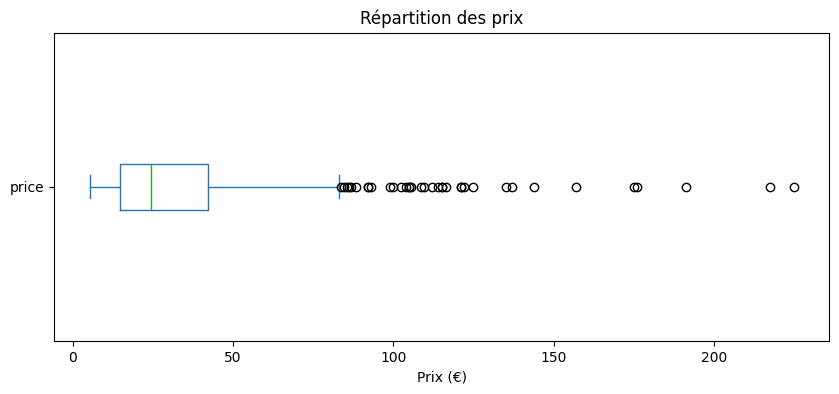

In [14]:
# Visualiser la distribution des prix avec une boîte à moustaches
df_final["price"].plot(kind="box", vert=False, figsize=(10, 4), title="Répartition des prix").set_xlabel("Prix (€)")

In [15]:
# Représentation interactive de la même distribution avec Plotly Express
fig = px.box(
    df_final,
    x="price",
    title="Répartition des prix (Plotly Express)",
    labels={"price": "Prix (€)"},
    points="all",
    color_discrete_sequence=["#a71c28"]
)

# Changer le fond bleu
fig.update_layout(
    plot_bgcolor="#f2f2f2",
    paper_bgcolor="#f2f2f2"
)

fig.show()

**Interprétation**

La distribution des prix est asymétrique : la médiane est de **24,40 €**, alors que certains produits atteignent **225 €**.

Le seuil IQR calculé plus loin est de **83,10 €**. Les valeurs supérieures à ce seuil doivent être considérées comme des produits atypiques à examiner, sans conclure automatiquement qu’il s’agit d’erreurs.

### 3.1.2 Identification statistique des prix atypiques

Deux méthodes sont comparées pour objectiver les valeurs élevées : le **Z-score** et l’**intervalle interquartile (IQR)**.

#### Méthode 1 — Z-score

Le Z-score mesure l’éloignement d’un prix par rapport à la moyenne en nombre d’écarts-types.

In [16]:
# Calculer la moyenne des prix
mean_price = df_final["price"].mean()
print(f"le prix moyen est de {mean_price:.2f} euros")

# Calculer l'écart-type des prix
std_price = df_final["price"].std()
print (f"l'écrat-type est de {std_price:.2f}")

# Calculer le Z-score de chaque prix
df_final["z_score"] = (df_final["price"] - mean_price) / std_price

le prix moyen est de 32.35 euros
l'écrat-type est de 26.62


In [17]:
# Calculer le prix correspondant à un Z-score supérieur à 3
mean_price = df_final["price"].mean()
std_price = df_final["price"].std()

seuil_z = mean_price + 3 * std_price
print(f"Le seuil de prix correspondant à un Z-score > 3 est : {seuil_z:.2f} euros")


Le seuil de prix correspondant à un Z-score > 3 est : 112.22 euros


**Résultat — Z-score**

Le prix moyen est de **32,35 €** et l’écart-type de **26,62 €**. Avec un seuil de trois écarts-types, un prix supérieur à **112,22 €** est considéré comme extrême selon cette méthode.

#### Méthode 2 — Intervalle interquartile (IQR)

L’IQR repose sur les quartiles et est moins sensible aux valeurs extrêmes. Le seuil supérieur est calculé par `Q3 + 1,5 × IQR`.

In [18]:
# Résumer la distribution des prix avec les statistiques descriptives
df_final["price"].describe()

,price
count,822.000000
mean,32.350304
std,26.622453
min,5.200000
25%,14.600000
50%,24.400000
75%,42.000000
max,225.000000


In [19]:
# Calculer le seuil supérieur de détection des prix atypiques par l'IQR
Q1 = df_final["price"].quantile(0.25)
Q3 = df_final["price"].quantile(0.75)
IQR = Q3 - Q1

seuil_IQR = Q3 + 1.5 * IQR
print(f"Le seuil IQR pour les outliers est : {seuil_IQR:.2f} euros")


Le seuil IQR pour les outliers est : 83.10 euros


In [20]:
# Compter les produits dont le prix dépasse le seuil IQR

# Isoler les prix supérieurs au seuil IQR calculé
outliers_IQR = df_final[df_final["price"] > seuil_IQR]
outliers_IQR

# Nombre de produits concernés
nb_outliers = outliers_IQR.shape[0]
print(f"Nombre d'outliers : {nb_outliers}")

# Part de ces produits dans la population consolidée
proportion_outliers = nb_outliers / df_final.shape[0]
print(f"Proportion d'outliers : {proportion_outliers:.2%}")



Nombre d'outliers : 36
Proportion d'outliers : 4.36%


In [21]:
# Afficher les produits concernés pour permettre une vérification métier
df_final[df_final["price"] > seuil_IQR][["product_id", "onsale_web","post_title", "product_type", "price"]]


,product_id,onsale_web,post_title,product_type,price
19,4055,0,NaN,NaN,86.1
66,4115,1,Zind-Humbrecht Riesling Grand Cru Rangen De Th...,Vin,100.0
68,4132,1,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,Vin,88.4
208,4352,1,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0
214,4359,1,Champagne Larmandier-Bernier Grand Cru Les Che...,Champagne,85.6
227,4402,1,Cognac Frapin VIP XO,Cognac,176.0
228,4404,1,Cognac Frapin Château de Fontpinot XO,Cognac,108.5
230,4406,1,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,157.0
231,4407,1,Cognac Frapin Cigar Blend,Cognac,104.0
240,4582,1,Château de Meursault Puligny-Montrachet 1er Cr...,Vin,109.6


## 3.2 Analyse des ventes, des stocks et de la marge

Cette partie étudie successivement le chiffre d’affaires, les quantités vendues, les stocks et la marge afin de compléter l’analyse du catalogue.

## 3.2.1 Chiffre d’affaires

**Question analysée :** quelle est la contribution économique du catalogue Web ?

Le notebook calcule d’abord le chiffre d’affaires par article (`price × total_sales`), puis :
- le chiffre d’affaires total ;
- le classement des 20 principaux contributeurs ;
- la part du catalogue nécessaire pour cumuler environ 80 % du CA.

**Résultat observé dans cette exécution :** chiffre d’affaires total de **139 815,40 €**.

In [22]:
# Calculer le chiffre d'affaires du site Web

# Calculer le chiffre d'affaires par article
df_final["ca_par_article"] = df_final["price"] * df_final["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
ca_total = df_final["ca_par_article"].sum()

# Agréger le chiffre d'affaires du catalogue
print(f"Le chiffre d'affaires total du site est de : {ca_total:.2f} euros")

Le chiffre d'affaires total du site est de : 139815.40 euros


In [23]:
# Classer les articles par chiffre d'affaires

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_palmares = df_final.sort_values(by="ca_par_article", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_palmares = df_palmares.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
df_palmares.head(20)

#Graphique en barre des 20 premiers articles avec plotly express

fig = px.bar(
    df_palmares.head(20),
    x="ca_par_article",
    y="post_title",
    title="Top 20 des articles en chiffre d'affaires",
    color_discrete_sequence=["#a71c28"]  # couleur des barres
)

# Tri des catégories
fig.update_yaxes(categoryorder='total ascending')

# Titres des axes
fig.update_layout(
    xaxis_title="CA",
    yaxis_title="Article",
    xaxis_tickangle=0,

    # Fond rouge très clair
    plot_bgcolor="#f2f2f2 ",
    paper_bgcolor="#f2f2f2"
)

fig.show()


In [24]:
# Mesurer la concentration cumulative du chiffre d'affaires

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_palmares["part_ca"] = df_palmares["ca_par_article"] / df_palmares["ca_par_article"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_palmares["part_ca_cum"] = df_palmares["part_ca"].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = df_palmares[df_palmares["part_ca_cum"] <= 0.8].shape[0]
nb_articles_80

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80 = nb_articles_80 / df_palmares.shape[0]
proportion_80

print(f"{nb_articles_80} articles représentant 80% du CA et constituent {proportion_80:.2%} du catalogue.")

413 articles représentant 80% du CA et constituent 50.06% du catalogue.


## 3.2.2 Volumes vendus

**Question analysée :** quels articles concentrent les quantités vendues ?

Le classement est établi à partir de `total_sales`, puis une analyse cumulative est utilisée pour mesurer la concentration des volumes.

In [25]:
# Classer les articles par quantité vendue

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_qte = df_final.sort_values(by="total_sales", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_qte = df_qte.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
df_qte.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    df_qte.head(20),
    x="total_sales",
    y="post_title",
    title="Top 20 des articles en quantité vendue",
    color_discrete_sequence=["#a71c28"],
)

fig.update_yaxes(categoryorder='total ascending')
fig.update_layout(xaxis_title="Quantité vendue", yaxis_title="Article", plot_bgcolor="#f2f2f2 ", paper_bgcolor="#f2f2f2")

fig.show()

In [26]:
# Mesurer la concentration cumulative des quantités vendues

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_qte["part_qte"] = df_qte["total_sales"] / df_qte["total_sales"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_qte["part_qte_cum"] = df_qte["part_qte"].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte = df_qte[df_qte["part_qte_cum"] <= 0.8].shape[0]
nb_articles_80_qte

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80_qte = nb_articles_80_qte / df_qte.shape[0]
proportion_80_qte

print(f"{nb_articles_80_qte} articles représentant 80% des ventes en quantité et constituent {proportion_80_qte:.2%} du catalogue.")

424 articles représentant 80% des ventes en quantité et constituent 51.39% du catalogue.


## 3.2.3 Stocks

**Questions analysées :**
- quels produits présentent la couverture de stock la plus élevée ?
- combien de produits restent en stock alors qu’ils ne sont pas rapprochés avec le Web ?
- quelle est la valeur totale du stock selon les prix disponibles ?

**Résultats observés dans cette exécution :**
- **64 produits** hors ligne disposent encore d’un stock ;
- cela représente **1 082 unités** ;
- la valorisation calculée du stock est de **531 946,20 €**.

La mesure de couverture de stock doit être interprétée avec prudence lorsque les ventes sont nulles ou négatives.

In [27]:
# Estimer une couverture de stock à partir du rapport stock / ventes

#Pour l'analyse des stocks, on utilise la df_final car elle prends en compte les produits qui sont hors ligne.

#Import de numpy

#Création de la colonne Rotation de stock
df_final["rotation_stock"] = df_final["stock_quantity"] / df_final["total_sales"]

#Remplacement des "inf" par 0
df_final["rotation_stock"] = df_final["rotation_stock"].replace([np.inf, -np.inf], 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock = df_final.sort_values(by="rotation_stock", ascending=False).reset_index(drop=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(
    df_stock.head(20),
    x="rotation_stock",
    y="post_title",
    title="Flop 20 des produits avec le plus de mois de stock",
    color_discrete_sequence=["#a71c28"],
)

fig.update_yaxes(categoryorder='total ascending')
fig.update_layout(xaxis_title="Mois de stock", yaxis_title="Article", plot_bgcolor="#f2f2f2 ", paper_bgcolor="#f2f2f2")

fig.show()

In [28]:
# Quantifier les produits non rapprochés au Web mais encore en stock
nb_produits_stock_hors_ligne = df_final[
    (df_final["_merge_final"] == "left_only") &
    (df_final["stock_quantity"] > 0)
].shape[0]

nb_produits_stock_hors_ligne

quantite_stock_hors_ligne = df_final[
    df_final["_merge_final"] == "left_only"
]["stock_quantity"].sum()

quantite_stock_hors_ligne

print(f"Il y a {nb_produits_stock_hors_ligne} produits hors ligne avec un stock.")
print(f"Il y a {quantite_stock_hors_ligne} unités de stock hors ligne.")

Il y a 64 produits hors ligne avec un stock.
Il y a 1082 unités de stock hors ligne.


In [29]:
# Valoriser le stock à partir du prix de vente disponible

#Création de la colonne Valorisation des stocks en euros
df_final["valorisation_stock_euros"] = df_final["stock_quantity"] * df_final["price"]

#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale = df_final["valorisation_stock_euros"].sum()
print(f"Valorisation totale des stocks : {valorisation_totale:.2f} euros")

Valorisation totale des stocks : 531946.20 euros


In [30]:
# Calculer le nombre total d'unités en stock

#Calculer la somme de la colonne stock quantity
total_unites_stock = df_final["stock_quantity"].sum()
print(f"Nombre total de produits en stock : {total_unites_stock}")

Nombre total de produits en stock : 17822


## 3.2.4 Marge

**Question analysée :** les produits en ligne présentent-ils des niveaux de marge homogènes ?

Le taux de marge est calculé à partir du prix HT et du prix d’achat. Le notebook isole ensuite les taux négatifs et compare les marges moyennes par type de produit.

**Résultat observé :** le taux minimum calculé est de **−86,39 %** ; ce cas doit être examiné comme une anomalie ou une situation métier particulière plutôt que corrigé automatiquement.

In [31]:
# Calculer le taux de marge des produits en ligne

#Filtre sur les produits en ligne
df_en_ligne = df_final[df_final["onsale_web"] == 1].copy()

#Création de la colonne Prix HT
df_en_ligne["prix_ht"] = df_en_ligne["price"] / 1.20

#Création de la colonne Taux de marge
df_en_ligne['taux_marge'] = ((df_en_ligne['prix_ht'] - df_en_ligne['purchase_price']) / df_en_ligne['purchase_price']) * 100

df_en_ligne['taux_marge'] = df_en_ligne['taux_marge'].round(2)
df_en_ligne['prix_ht'] = df_en_ligne['prix_ht'].round(2)

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Taux de marge minimum : {df_en_ligne['taux_marge'].min()}%")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Taux de marge maximum : {df_en_ligne['taux_marge'].max()}%")

Taux de marge minimum : -86.39%
Taux de marge maximum : 91.41%


In [32]:
# Identifier les produits dont le taux de marge calculé est négatif
df_en_ligne[df_en_ligne["taux_marge"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,price_source,stock_quantity_source,stock_status_source,onsale_web_source,id_web,web_join_key,_merge_erp_liaison,sku,post_title,product_type,post_type,total_sales,guid,product_id_web,_merge_final,presence_web,statut_vente,z_score,ca_par_article,rotation_stock,valorisation_stock_euros,prix_ht,taux_marge
210,4355,1,12.65,97,instock,77.48,12.65,97,instock,1,12589,sku:12589,both,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Champagne,product,0.0,https://www.bottle-neck.fr/?post_type=product&...,4355,both,True,en_ligne,-0.739988,0.0,0.0,1227.05,10.54,-86.39


In [33]:
# Isoler les taux de marge positifs pour décrire leur étendue
df_marge_positive = df_en_ligne[df_en_ligne["taux_marge"] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
df_marge_positive["taux_marge"].min()

#Afficher le prix maximum de la colonne "taux_marge"
df_marge_positive["taux_marge"].max()

print(f"Taux de marge minimum (positif) : {df_marge_positive['taux_marge'].min()}%")
print(f"Taux de marge maximum : {df_marge_positive['taux_marge'].max()}%")

Taux de marge minimum (positif) : 29.5%
Taux de marge maximum : 91.41%


In [34]:
# Calculer le taux de marge moyen par type de produit
df_marge_par_type = df_en_ligne.groupby("product_type")["taux_marge"].mean().reset_index()

df_marge_par_type = df_marge_par_type.sort_values("taux_marge", ascending=False)
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_par_type,
    x="product_type",
    y="taux_marge",
    title="Taux de marge moyen par type de produit",
    text="taux_marge",
    color_discrete_sequence=["#a71c28"],
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(
    xaxis_title="Type de produit",
    yaxis_title="Taux de marge moyen",
    plot_bgcolor="#f2f2f2 ",
    paper_bgcolor="#f2f2f2"
)
fig.show()

# 4. Relations entre stock, ventes et prix

Une matrice de corrélation est utilisée pour explorer les associations linéaires entre :
- `stock_quantity` ;
- `total_sales` ;
- `price`.

Cette analyse est **exploratoire** : une corrélation décrit une association statistique et ne permet pas, à elle seule, d’établir une causalité.

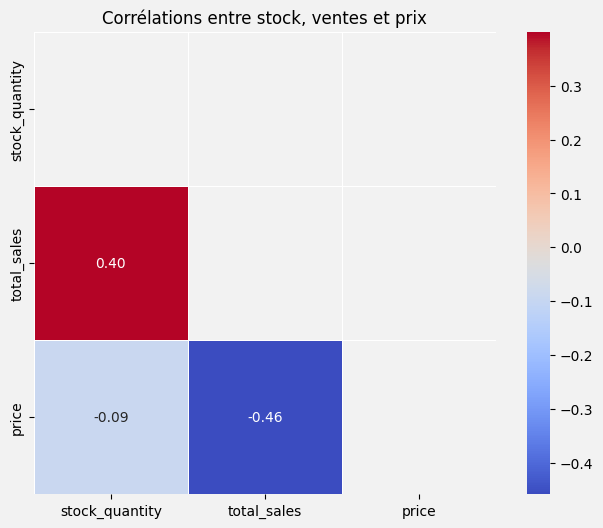

In [35]:
# Calculer les corrélations entre stock, ventes et prix

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

df_corr = df_final[["stock_quantity", "total_sales", "price"]]

corr_matrix = df_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))

# Définir un fond gris clair pour la figure
plt.gcf().patch.set_facecolor("#f2f2f2")

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=mask,
    linewidths=0.5,
    square=True
)

# Définir aussi le fond gris clair derrière la heatmap
ax.set_facecolor("#f2f2f2")

plt.title("Corrélations entre stock, ventes et prix")
plt.show()


In [36]:
# Cellule réservée à l'interprétation des corrélations observées

# 5. Segmentation des produits avec K-Means

Cette section intègre l’**amélioration n°4 du P11** après comparaison de K-Means et du clustering hiérarchique agglomératif.

**Objectif :** croiser ventes, marge et stock pour faire émerger une population de produits à examiner en priorité.

Trois variables sont utilisées :
- `total_sales` : performance commerciale ;
- taux de marge recalculé à précision complète : rentabilité ;
- `stock_quantity` : niveau de stock.

Deux produits avec ventes négatives sont exclus du clustering car ils correspondent à des mouvements particuliers déjà identifiés dans le P6. La segmentation est un **outil de priorisation** : elle ne déclenche aucune décision automatique.

## 5.1 Préparation de la population

La segmentation porte uniquement sur les produits commercialisés en ligne disposant des variables nécessaires. Les données sont mises à l’échelle avec `RobustScaler` afin de rendre les trois dimensions comparables.

In [37]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

if "presence_web" in df_final.columns:
    masque_web_seg = df_final["presence_web"].astype(bool)
elif "onsale_web" in df_final.columns:
    masque_web_seg = df_final["onsale_web"].eq(1)
else:
    raise KeyError("Impossible d'identifier les produits commercialisés en ligne.")

df_seg = df_final.loc[
    masque_web_seg,
    [
        "product_id", "post_title", "product_type",
        "price", "purchase_price", "total_sales", "stock_quantity"
    ]
].copy()

# Même formule de marge que dans le P6, conservée à précision complète
# pour éviter qu'un arrondi intermédiaire influence le clustering.
df_seg["prix_ht_segmentation"] = df_seg["price"] / 1.20
df_seg["taux_marge_segmentation"] = (
    (df_seg["prix_ht_segmentation"] - df_seg["purchase_price"])
    / df_seg["purchase_price"]
) * 100

variables_segmentation = [
    "total_sales", "taux_marge_segmentation", "stock_quantity"
]

df_seg = df_seg.dropna(subset=variables_segmentation).copy()

ventes_negatives_seg = df_seg.loc[
    df_seg["total_sales"] < 0,
    ["product_id", "post_title", "total_sales"]
].copy()

df_seg = df_seg.loc[df_seg["total_sales"] >= 0].reset_index(drop=True)

scaler_seg = RobustScaler()
X_seg = scaler_seg.fit_transform(df_seg[variables_segmentation])

resume_segmentation = pd.DataFrame({
    "Indicateur": [
        "Produits en ligne",
        "Ventes négatives exclues",
        "Produits retenus pour K-Means",
    ],
    "Valeur": [
        int(masque_web_seg.sum()),
        len(ventes_negatives_seg),
        len(df_seg),
    ],
})

display(resume_segmentation)
display(ventes_negatives_seg)

assert int(masque_web_seg.sum()) == 716
assert set(ventes_negatives_seg["product_id"].astype(int)) == {5070, 5075}
assert len(df_seg) == 714

,Indicateur,Valeur
0,Produits en ligne,716
1,Ventes négatives exclues,2
2,Produits retenus pour K-Means,714


,product_id,post_title,total_sales
486,5070,Pierre Jean Villa Côte Rôtie Fongeant 2017,-17.0
487,5075,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-56.0


## 5.2 Choix du nombre de groupes

Les solutions de **2 à 6 clusters** sont comparées avec le score de silhouette. Cette métrique aide à mesurer la cohésion et la séparation des groupes, mais elle ne suffit pas à elle seule : l’interprétabilité métier reste déterminante.

In [38]:
resultats_silhouette = []

for k in range(2, 7):
    modele_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )
    labels_k = modele_k.fit_predict(X_seg)

    resultats_silhouette.append({
        "Nombre de groupes": k,
        "Score de silhouette": silhouette_score(X_seg, labels_k),
    })

scores_silhouette = pd.DataFrame(resultats_silhouette)
display(scores_silhouette.round(4))

meilleur_k = int(
    scores_silhouette.loc[
        scores_silhouette["Score de silhouette"].idxmax(),
        "Nombre de groupes"
    ]
)

print(f"Nombre de groupes retenu : {meilleur_k}")
assert meilleur_k == 2
assert abs(
    scores_silhouette.loc[
        scores_silhouette["Nombre de groupes"].eq(2),
        "Score de silhouette"
    ].iloc[0] - 0.7214
) < 0.001

,Nombre de groupes,Score de silhouette
0,2,0.7214
1,3,0.3763
2,4,0.3791
3,5,0.3596
4,6,0.3221


Nombre de groupes retenu : 2


## 5.3 K-Means à 2 segments

Le modèle final est ajusté avec `k=2`, `random_state=42` et `n_init=10`. Les libellés métier sont attribués **après** observation des profils : le petit groupe est identifié comme population à surveiller, sans considérer automatiquement ses produits comme problématiques.

In [39]:
modele_kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10,
)

df_seg["cluster_kmeans"] = modele_kmeans_final.fit_predict(X_seg)

tailles_clusters = df_seg["cluster_kmeans"].value_counts()
cluster_prioritaire = tailles_clusters.idxmin()

df_seg["segment_kmeans"] = np.where(
    df_seg["cluster_kmeans"].eq(cluster_prioritaire),
    "À surveiller en priorité",
    "Profil courant du catalogue",
)

profil_segments = (
    df_seg.groupby("segment_kmeans")
    .agg(
        nombre_produits=("product_id", "size"),
        ventes_moyennes=("total_sales", "mean"),
        ventes_medianes=("total_sales", "median"),
        marge_moyenne=("taux_marge_segmentation", "mean"),
        marge_mediane=("taux_marge_segmentation", "median"),
        stock_moyen=("stock_quantity", "mean"),
        stock_median=("stock_quantity", "median"),
        prix_moyen=("price", "mean"),
        prix_median=("price", "median"),
    )
    .round(2)
    .reset_index()
)

display(profil_segments)

assert sorted(profil_segments["nombre_produits"].tolist()) == [29, 685]

,segment_kmeans,nombre_produits,ventes_moyennes,ventes_medianes,marge_moyenne,marge_mediane,stock_moyen,stock_median,prix_moyen,prix_median
0,Profil courant du catalogue,685,8.10,8.0,62.05,61.29,19.85,19.0,31.14,22.9
1,À surveiller en priorité,29,7.03,6.0,36.58,40.05,108.28,103.0,60.48,51.6


## 5.4 Intégration du segment à la table consolidée

Le résultat est ajouté à `df_final` pour être disponible dans l’export. Les produits non concernés par le clustering restent explicitement hors segmentation.

In [40]:
# Valeur par défaut pour les produits hors population du clustering.
df_final["segment_kmeans"] = np.where(
    masque_web_seg,
    "Hors segmentation",
    "Hors segmentation — non commercialisé en ligne",
)

# Identifier spécifiquement les deux ventes négatives exclues.
ids_ventes_negatives = set(ventes_negatives_seg["product_id"].tolist())
df_final.loc[
    df_final["product_id"].isin(ids_ventes_negatives),
    "segment_kmeans"
] = "Hors segmentation — vente négative"

# Reporter les segments K-Means sur les 714 produits analysés.
mapping_segments = df_seg.set_index("product_id")["segment_kmeans"]
df_final.loc[
    df_final["product_id"].isin(mapping_segments.index),
    "segment_kmeans"
] = df_final.loc[
    df_final["product_id"].isin(mapping_segments.index),
    "product_id"
].map(mapping_segments)

display(df_final["segment_kmeans"].value_counts().rename_axis("Segment").reset_index(name="Produits"))

,Segment,Produits
0,Profil courant du catalogue,685
1,Hors segmentation — non commercialisé en ligne,109
2,À surveiller en priorité,29
3,Hors segmentation — vente négative,2


## 5.5 Visualisation et interprétation

La PCA ci-dessous sert uniquement à visualiser les trois dimensions du clustering sur deux axes. Elle n’est pas utilisée pour créer les segments.

In [41]:
pca_seg = PCA(n_components=2)
projection_seg = pca_seg.fit_transform(X_seg)

df_seg["PCA1"] = projection_seg[:, 0]
df_seg["PCA2"] = projection_seg[:, 1]

variance_expliquee = pca_seg.explained_variance_ratio_.sum()
print(f"Variance expliquée par les deux composantes : {variance_expliquee:.1%}")

fig = px.scatter(
    df_seg,
    x="PCA1",
    y="PCA2",
    color="segment_kmeans",
    hover_data=[
        "product_id", "post_title", "total_sales",
        "taux_marge_segmentation", "stock_quantity", "price"
    ],
    title="K-Means — projection PCA des segments de produits",
)
fig.show()

Variance expliquée par les deux composantes : 89.1%


**Interprétation**

K-Means distingue principalement une petite population de **29 produits** du reste du catalogue :

- le **profil courant du catalogue** regroupe 685 produits, avec environ **8,10 ventes moyennes**, **62,05 % de marge moyenne**, **19,85 unités de stock moyen** et un prix moyen d’environ **31,14 €** ;
- le segment **« À surveiller en priorité »** regroupe 29 produits, avec environ **7,03 ventes moyennes**, **36,58 % de marge moyenne**, **108,28 unités de stock moyen** et un prix moyen d’environ **60,48 €**.

Le segment minoritaire présente donc un niveau de stock nettement supérieur sans performance de vente supérieure, ainsi qu’une marge moyenne plus faible. Il constitue une **population à examiner en priorité**, et non une catégorie automatiquement problématique.

Cette lecture est cohérente avec le test de clustering hiérarchique, qui isole une population très proche. K-Means est retenu pour sa simplicité de réutilisation et son score de silhouette légèrement supérieur.

# 6. Mise à disposition de la table consolidée

La table `df_final`, enrichie par les contrôles qualité, les rapprochements et les indicateurs calculés, est exportée au format Excel.

Cet export constitue le point de sortie réutilisable du notebook pour une analyse complémentaire ou une restitution dans un autre outil.

In [42]:
# Export de la table consolidée
fichier_export = "df_merge_final.xlsx"
df_final.to_excel(fichier_export, index=False)
print(f"Fichier exporté : {fichier_export}")

# Téléchargement automatique uniquement dans Google Colab.
try:
    from google.colab import files
    files.download(fichier_export)
except Exception:
    print("Hors Colab : le fichier reste disponible dans le dossier courant.")

Fichier exporté : df_merge_final.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>